In [43]:
import numpy as np
import pandas as pd

import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

from tqdm.notebook import tqdm
from IPython.display import clear_output

In [44]:
class ResidualBlock(nn.Module):
    def __init__(self, dim, dropout=0.3):
        super().__init__()
        self.fc = nn.Sequential(
            nn.Linear(dim, dim),
            nn.BatchNorm1d(dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(dim, dim),
            nn.BatchNorm1d(dim)
        )
        self.relu = nn.ReLU()

    def forward(self, x):
        residual = x
        out = self.fc(x)
        out = out + residual
        return self.relu(out)

class ATMNet(nn.Module):
    def __init__(self, input_size, hidden_size=256, dropout=0.3):
        super().__init__()

        # Входной слой
        self.input_layer = nn.Sequential(
            nn.Linear(input_size, 256),
            nn.BatchNorm1d(256),
            nn.ReLU()
        )

        # Residual блоки
        self.res_block1 = ResidualBlock(256)
        self.res_block2 = ResidualBlock(256)

        # Выходной слой
        self.output = nn.Linear(256, 1)

    def forward(self, x):
        x = self.input_layer(x)
        x = self.res_block1(x)
        x = self.res_block2(x)
        return self.output(x).squeeze(-1)

class ResidualEnsemble(nn.Module):
    def __init__(self, input_size, n_models=3, hidden_size=256, dropout=0.3):
        super().__init__()

        # Создаем несколько моделей с разными seed для разнообразия
        self.models = nn.ModuleList()
        for i in range(n_models):
            # Фиксируем seed для каждой модели (опционально)
            torch.manual_seed(42 + i)
            model = ATMNet(input_size, hidden_size, dropout)
            self.models.append(model)

        # Возвращаем seed (если нужно)
        torch.manual_seed(42)

    def forward(self, x):
        predictions = []
        for model in self.models:
            predictions.append(model(x))

        # Усредняем предсказания
        return torch.stack(predictions).mean(dim=0)

In [33]:
def plot_losses(train_losses, train_metrics, val_losses, val_metrics):

    clear_output()
    fig, axs = plt.subplots(1, 2, figsize=(15, 5))
    axs[0].plot(range(1, len(train_losses) + 1), train_losses, label="train")
    axs[0].plot(range(1, len(val_losses) + 1), val_losses, label="val")
    axs[1].plot(range(1, len(train_metrics) + 1), train_metrics, label="train")
    axs[1].plot(range(1, len(val_metrics) + 1), val_metrics, label="val")

    if max(train_losses) / min(train_losses) > 10:
        axs[0].set_yscale("log")

    if max(train_metrics) / min(train_metrics) > 10:
        axs[1].set_yscale("log")

    for ax in axs:
        ax.set_xlabel("epoch")
        ax.legend()

    axs[0].set_ylabel("loss")
    axs[1].set_ylabel("MSE")
    plt.show()


def train_and_validate(
    model,
    optimizer,
    criterion,
    metric,
    train_loader,
    val_loader,
    num_epochs,
    verbose=True,
):

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)

    train_losses, val_losses = [], []
    train_metrics, val_metrics = [], []

    for epoch in range(1, num_epochs + 1):
        model.train()
        running_loss, running_metric = 0, 0
        pbar = (
            tqdm(train_loader, desc=f"Training {epoch}/{num_epochs}")
            if verbose
            else train_loader
        )

        for i, (X_batch, y_batch) in enumerate(pbar, 1):

            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            optimizer.zero_grad()

            predictions = model(X_batch)
            loss = criterion(predictions, y_batch)

            loss.backward()
            optimizer.step()

            with torch.no_grad():
                metric_value = metric(predictions, y_batch)
                if type(metric_value) == torch.Tensor:
                    metric_value = metric_value.item()
                running_loss += loss.item() * X_batch.shape[0]
                running_metric += metric_value * X_batch.shape[0]

            if verbose and i % 100 == 0:
                pbar.set_postfix({"loss": loss.item(), "MSE": metric_value})

        train_losses += [running_loss / len(train_loader.dataset)]
        train_metrics += [running_metric / len(train_loader.dataset)]

        model.eval()
        running_loss, running_metric = 0, 0
        pbar = (
            tqdm(val_loader, desc=f"Validating {epoch}/{num_epochs}")
            if verbose
            else val_loader
        )

        for i, (X_batch, y_batch) in enumerate(pbar, 1):
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            with torch.no_grad():

                predictions = model(X_batch)
                loss = criterion(predictions, y_batch)

                metric_value = metric(predictions, y_batch)
                if type(metric_value) == torch.Tensor:
                    metric_value = metric_value.item()
                running_loss += loss.item() * X_batch.shape[0]
                running_metric += metric_value * X_batch.shape[0]

            if verbose and i % 100 == 0:
                pbar.set_postfix({"loss": loss.item(), "MSE": metric_value})

        val_losses += [running_loss / len(val_loader.dataset)]
        val_metrics += [running_metric / len(val_loader.dataset)]

        if verbose:
            plot_losses(train_losses, train_metrics, val_losses, val_metrics)

    if verbose:
        print(f"Validation MSE: {val_metrics[-1]:.3f}")

    return train_metrics[-1], val_metrics[-1]

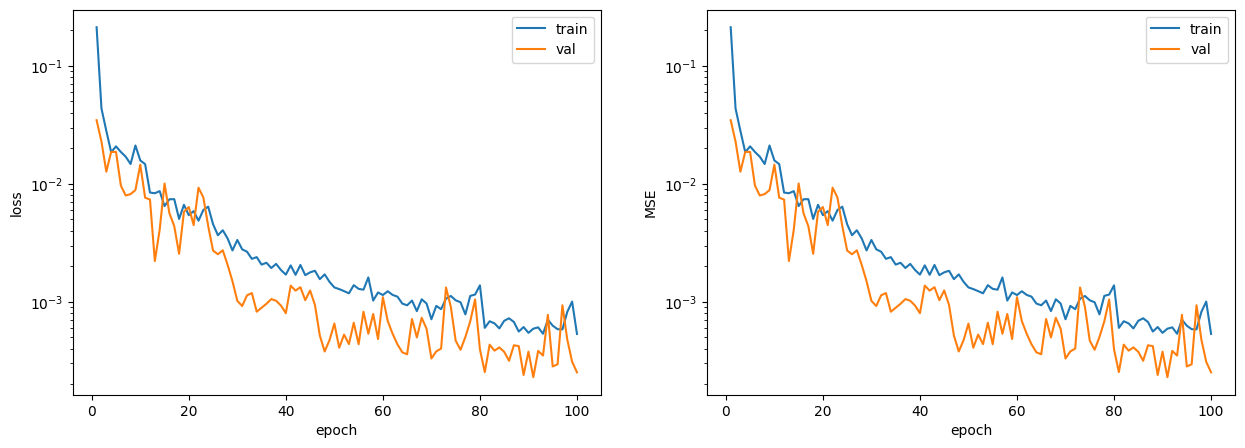

Validation MSE: 0.000

Результаты:
Train MSE: 0.0005
Val MSE: 0.0003
Val RMSE: 0.0159


In [52]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from tqdm import tqdm
import matplotlib.pyplot as plt

df = pd.read_csv("train_final.csv")

def clean_numeric_strings(df):
    for col in df.columns:
        if df[col].dtype == 'object':
            try:
                cleaned = df[col].astype(str).str.replace(' ', '', regex=False)
                cleaned = cleaned.str.replace(',', '.', regex=False)
                numeric_values = pd.to_numeric(cleaned, errors='coerce')
                if numeric_values.notna().sum() > len(df) * 0.8:
                    df[col] = numeric_values
                    print(f"✓ {col}: преобразован в числовой")
                else:
                    print(f"  {col}: остается категориальным (успешно: {numeric_values.notna().sum()}/{len(df)})")
            except Exception as e:
                print(f"  {col}: остается категориальным ({str(e)[:50]})")
    return df

df = clean_numeric_strings(df)

y = df['target']
X = df.drop(['Unnamed: 0', 'id', 'address', 'address_rus'], axis=1, errors='ignore')

if 'atm_group' in X.columns:
    X = pd.get_dummies(X, columns=['atm_group'], drop_first=True)
    print(f"One-hot кодирование atm_group выполнено")

print(f"\nПропуски в y: {y.isnull().sum()}")
if y.isnull().any():
    print(f"Удаляем {y.isnull().sum()} строк с пропусками в target")
    mask = ~y.isnull()
    X = X[mask]
    y = y[mask]
    print(f"После удаления: X shape={X.shape}, y shape={y.shape}")

object_cols = X.select_dtypes(include=['object']).columns
if len(object_cols) > 0:
    print(f"\nПреобразуем object столбцы: {list(object_cols)}")
    for col in object_cols:
        X[col] = pd.to_numeric(X[col], errors='coerce')
        print(f"  {col}: преобразован")

print(f"\nПропуски в X до заполнения: {X.isnull().sum().sum()}")
imputer = SimpleImputer(strategy='median')
X_imputed = pd.DataFrame(
    imputer.fit_transform(X),
    columns=X.columns,
    index=X.index
)
print(f"Пропуски в X после заполнения: {X_imputed.isnull().sum().sum()}")

X_temp, X_test, y_temp, y_test = train_test_split(
    X_imputed, y,
    test_size=0.2,
    random_state=42,
    shuffle=True
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp,
    test_size=0.2,
    random_state=42,
    shuffle=True
)

print(f"\nРазмеры:")
print(f"Train: {X_train.shape}")
print(f"Val: {X_val.shape}")
print(f"Test: {X_test.shape}")

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

if np.isnan(X_train_scaled).any():
    X_train_scaled = np.nan_to_num(X_train_scaled, nan=0.0)
    X_val_scaled = np.nan_to_num(X_val_scaled, nan=0.0)
    X_test_scaled = np.nan_to_num(X_test_scaled, nan=0.0)

train_dataset = TensorDataset(
    torch.FloatTensor(X_train_scaled),
    torch.FloatTensor(y_train.values)
)
val_dataset = TensorDataset(
    torch.FloatTensor(X_val_scaled),
    torch.FloatTensor(y_val.values)
)
test_dataset = TensorDataset(
    torch.FloatTensor(X_test_scaled),
    torch.FloatTensor(y_test.values)
)

train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True, generator=torch.Generator().manual_seed(42))
val_loader = DataLoader(val_dataset, batch_size=256, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=256, shuffle=False)

print(f"Train batches: {len(train_loader)}")
print(f"Val batches: {len(val_loader)}")
print(f"Test batches: {len(test_loader)}")

model = ResidualEnsemble(
    input_size=X_train_scaled.shape[1],
    n_models=3,
    hidden_size=256,
    dropout=0.3
)


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

test_input = torch.FloatTensor(X_train_scaled[:32]).to(device)
model.eval()
with torch.no_grad():
    test_output = model(test_input)

optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = nn.MSELoss()
metric = nn.MSELoss()

train_mse, val_mse = train_and_validate(
    model=model,
    optimizer=optimizer,
    criterion=criterion,
    metric=metric,
    train_loader=train_loader,
    val_loader=val_loader,
    num_epochs=100,
    verbose=True
)

print(f"\nРезультаты:")
print(f"Train MSE: {train_mse:.4f}")
print(f"Val MSE: {val_mse:.4f}")
print(f"Val RMSE: {np.sqrt(val_mse):.4f}")

In [54]:
model.eval()
test_preds = []
test_true = []

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        y_pred = model(X_batch)

        test_preds.extend(y_pred.cpu().numpy())
        test_true.extend(y_batch.numpy())

# Вычисляем RMSE на тесте
test_mse = mean_squared_error(test_true, test_preds)
test_rmse = np.sqrt(test_mse)

In [60]:
print(f'test_mse - {test_mse:.4f}')
print(f'test_rmse - {test_rmse:.4f}')

test_mse - 0.0003
test_rmse - 0.0161


In [61]:
print(f"Target statistics:")
print(f"Min: {y.min():.4f}")
print(f"Max: {y.max():.4f}")
print(f"Mean: {y.mean():.4f}")
print(f"Std: {y.std():.4f}")

# Относительная ошибка (RMSE / std)
relative_error = test_rmse / y.std()
print(f"Relative RMSE (RMSE/std): {relative_error:.4f}")

Target statistics:
Min: -0.1450
Max: 0.2186
Mean: 0.0007
Std: 0.0858
Relative RMSE (RMSE/std): 0.1877


In [63]:
torch.save(model.state_dict(), 'neural_network_ensemble.pth')

## Метрики на тестовой выборке

| Модель | RMSE | R² | Относительное улучшение |
|--------|------|-----|------------------------|
| **Градиентный бустинг** | 0.0143 | 0.9577 | baseline |
| **Нейросеть (Residual Ensemble)** | 0.0161 | 0.9650 | -12.6% (хуже) |

## Ключевые выводы

1. Ранее **Градиентный бустинг** показал лучший результат среди отдельных моделей
2. **Нейросеть с residual connections** (ансамбль из 3 моделей)продемонстрировала конкурентоспособное качество (R2 выше, но RMSE хуже)